Feature scaling -> max-min normalization
x(scaled)=x(i) -x (min) /x(max)-x(min)

In [65]:
!pip install scikit-learn


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [66]:
#import the libraries
import numpy as np
import pandas as pd
import sklearn

In [67]:
data = pd.DataFrame({'Price_USA':[80,50,140,25],'Price_INR':[5000,7000,12000,3000]})
data

,Price_USA,Price_INR
0,80,5000
1,50,7000
2,140,12000
3,25,3000


In [68]:
#We will perform mathmatical wise
data['Price_USA_minimax'] = (data['Price_USA'] - data['Price_USA'].min()) / (data['Price_USA'].max() - data['Price_USA'].min())
data

,Price_USA,Price_INR,Price_USA_minimax
0,80,5000,0.478261
1,50,7000,0.217391
2,140,12000,1.000000
3,25,3000,0.000000


In [69]:
data['Price_INR_minimax'] = (data['Price_INR'] - data['Price_INR'].min()) / (data['Price_INR'].max() - data['Price_INR'].min())
data

,Price_USA,Price_INR,Price_USA_minimax,Price_INR_minimax
0,80,5000,0.478261,0.222222
1,50,7000,0.217391,0.444444
2,140,12000,1.000000,1.000000
3,25,3000,0.000000,0.000000


In [70]:
import sklearn

In [71]:
from sklearn.preprocessing import MinMaxScaler,StandardScaler

In [72]:
min_max = MinMaxScaler()

In [73]:
#we need to use fit_transform()
data['Price_USA_minsk']=min_max.fit_transform(data[['Price_USA']])
data

,Price_USA,Price_INR,Price_USA_minimax,Price_INR_minimax,Price_USA_minsk
0,80,5000,0.478261,0.222222,0.478261
1,50,7000,0.217391,0.444444,0.217391
2,140,12000,1.000000,1.000000,1.000000
3,25,3000,0.000000,0.000000,0.000000


In [74]:
#Standardization (StandardScaler) = x(i) - mean/std

In [75]:
data['Price_USA_std']=(data['Price_USA'] - data['Price_USA'].mean()) / (data['Price_USA'].std())
data

,Price_USA,Price_INR,Price_USA_minimax,Price_INR_minimax,Price_USA_minsk,Price_USA_std
0,80,5000,0.478261,0.222222,0.478261,0.126108
1,50,7000,0.217391,0.444444,0.217391,-0.479212
2,140,12000,1.000000,1.000000,1.000000,1.336748
3,25,3000,0.000000,0.000000,0.000000,-0.983645


In [76]:
data['Price_INR_std']=(data['Price_INR'] - data['Price_INR'].mean()) / (data['Price_INR'].std())
data

,Price_USA,Price_INR,Price_USA_minimax,Price_INR_minimax,Price_USA_minsk,Price_USA_std,Price_INR_std
0,80,5000,0.478261,0.222222,0.478261,0.126108,-0.453108
1,50,7000,0.217391,0.444444,0.217391,-0.479212,0.064730
2,140,12000,1.000000,1.000000,1.000000,1.336748,1.359325
3,25,3000,0.000000,0.000000,0.000000,-0.983645,-0.970947


In [77]:
from sklearn.preprocessing import RobustScaler

In [78]:
robust=RobustScaler()

In [79]:
data['Price_USA_robust']=robust.fit_transform(data[['Price_USA']])
data['Price_USA_robust']

0    0.292683
1   -0.292683
2    1.463415
3   -0.780488
Name: Price_USA_robust, dtype: float64

In [80]:
data['Price_INR_robust']=robust.fit_transform(data[['Price_INR']])
data['Price_INR_robust']

0   -0.266667
1    0.266667
2    1.600000
3   -0.800000
Name: Price_INR_robust, dtype: float64

## Regression on Case Study related to predicting Miles Per Gallon (mpg)
#Scenario as follows: 

A Fleet manager wanted to calculate (predict) the mpg efficiency of his vehicles based on ( cylinders, weight, displacement , acceleration , horsepower)..
we will be UCIML repo package to fetch,load and transform the data from UCI repo

In [81]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Assume the actual and prdicted values are:
Actual    Predicted    Error   Absolute error   Squared error
20        22           -2      2                 4
30        28            2      2                 4
40        35            5      5                 25

In [82]:
#step 1: import the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [83]:
from ucimlrepo import fetch_ucirepo
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import OneHotEncoder,PolynomialFeatures
from sklearn.metrics import mean_absolute_error,mean_absolute_error,r2_score 
sns.set_style(style= 'whitegrid') #backgrund style of graphs

In [84]:
#step2: loading and cleaning the data
data = fetch_ucirepo(id=9)
data
X = data.data.features.copy() #it returns all numerical features
Y = data.data.targets['mpg']

In [85]:
X.describe()

,displacement,cylinders,horsepower,weight,acceleration,model_year,origin
count,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000,398.000000
mean,193.425879,5.454774,104.469388,2970.424623,15.568090,76.010050,1.572864
std,104.269838,1.701004,38.491160,846.841774,2.757689,3.697627,0.802055
min,68.000000,3.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,104.250000,4.000000,75.000000,2223.750000,13.825000,73.000000,1.000000
50%,148.500000,4.000000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,262.000000,8.000000,126.000000,3608.000000,17.175000,79.000000,2.000000
max,455.000000,8.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


In [86]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   displacement  398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   horsepower    392 non-null    float64
 3   weight        398 non-null    int64  
 4   acceleration  398 non-null    float64
 5   model_year    398 non-null    int64  
 6   origin        398 non-null    int64  
dtypes: float64(3), int64(4)
memory usage: 21.9 KB


In [87]:
X['origin'].unique();
X['horsepower'].unique()

array([130., 165., 150., 140., 198., 220., 215., 225., 190., 170., 160.,
        95.,  97.,  85.,  88.,  46.,  87.,  90., 113., 200., 210., 193.,
        nan, 100., 105., 175., 153., 180., 110.,  72.,  86.,  70.,  76.,
        65.,  69.,  60.,  80.,  54., 208., 155., 112.,  92., 145., 137.,
       158., 167.,  94., 107., 230.,  49.,  75.,  91., 122.,  67.,  83.,
        78.,  52.,  61.,  93., 148., 129.,  96.,  71.,  98., 115.,  53.,
        81.,  79., 120., 152., 102., 108.,  68.,  58., 149.,  89.,  63.,
        48.,  66., 139., 103., 125., 133., 138., 135., 142.,  77.,  62.,
       132.,  84.,  64.,  74., 116.,  82.])

In [88]:
#first we will transform the horsepower and origin columns
X['horsepower'] = pd.to_numeric(X['horsepower'],errors='coerce')
X['horsepower'].info()
X['origin'] = X['origin'].astype(str)

<class 'pandas.Series'>
RangeIndex: 398 entries, 0 to 397
Series name: horsepower
Non-Null Count  Dtype  
--------------  -----  
392 non-null    float64
dtypes: float64(1)
memory usage: 3.2 KB


In [89]:
X.info();
#All numerical columns into a single collections
numerical_features = ['cylinders','displacement','horsepower','weight','acceleration','model_year']
categorical_features = ['origin']
X = X[numerical_features + categorical_features]
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   displacement  398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   horsepower    392 non-null    float64
 3   weight        398 non-null    int64  
 4   acceleration  398 non-null    float64
 5   model_year    398 non-null    int64  
 6   origin        398 non-null    str    
dtypes: float64(3), int64(3), str(1)
memory usage: 22.3 KB
<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   cylinders     398 non-null    int64  
 1   displacement  398 non-null    float64
 2   horsepower    392 non-null    float64
 3   weight        398 non-null    int64  
 4   acceleration  398 non-null    float64
 5   model_year    398 non-null    int64  
 6   origin        398 n

In [90]:
X.isnull().sum()

cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
dtype: int64

In [91]:
X.shape

(398, 7)

In [92]:
#step-3: Quick Exploratory Data Analysis (Seaborn)
df = X.copy()
df['mpg']=Y

In [93]:
df

,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,mpg
0,8,307.0,130.0,3504,12.0,70,1,18.0
1,8,350.0,165.0,3693,11.5,70,1,15.0
2,8,318.0,150.0,3436,11.0,70,1,18.0
3,8,304.0,150.0,3433,12.0,70,1,16.0
4,8,302.0,140.0,3449,10.5,70,1,17.0
...,...,...,...,...,...,...,...,...
393,4,140.0,86.0,2790,15.6,82,1,27.0
394,4,97.0,52.0,2130,24.6,82,2,44.0
395,4,135.0,84.0,2295,11.6,82,1,32.0
396,4,120.0,79.0,2625,18.6,82,1,28.0


<Axes: xlabel='mpg', ylabel='Count'>

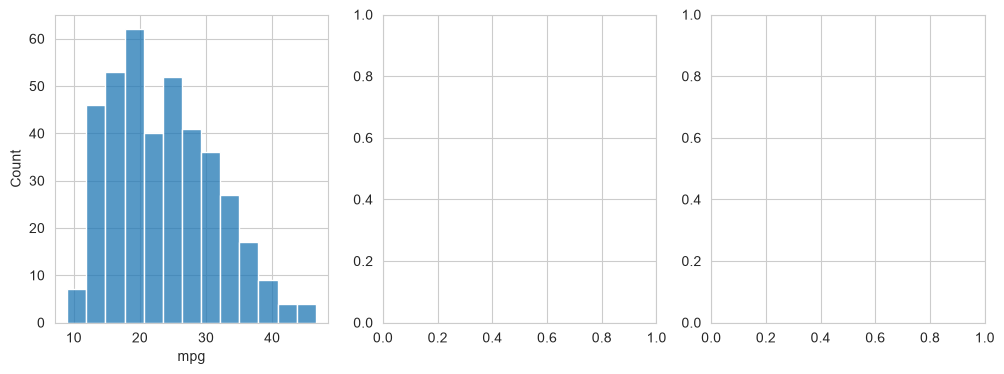

In [94]:
#We are mapping input and target variables into the dataframe
fig,axes = plt.subplots(1,3,figsize=(12,4))
#plot graphs as per axes
sns.histplot(df['mpg'],kde=False,ax=axes[0])

Text(0.5, 1.0, 'HorsePower MPG Distribution')

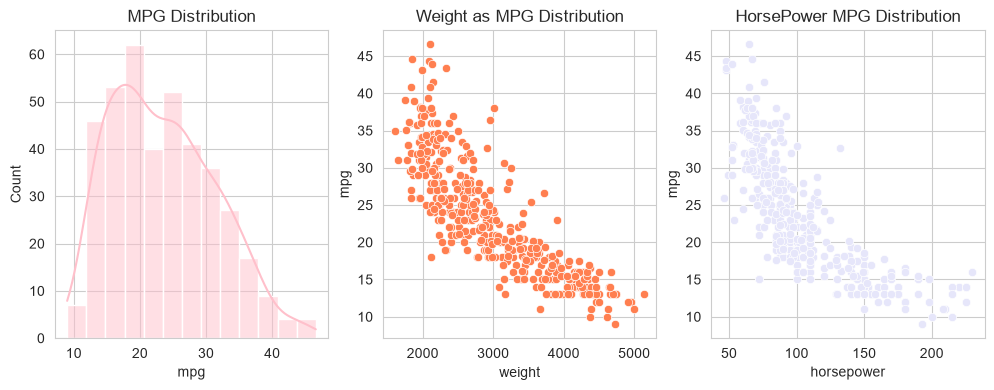

In [95]:
#We are mapping input and target variables into the dataframe
fig,axes = plt.subplots(1,3,figsize=(12,4))
#plot graphs as per axes
sns.histplot(df['mpg'],kde=True,ax=axes[0],color='pink')
#in similar way we display other graphs in rmng plots
axes[0].set_title("MPG Distribution")
sns.scatterplot(x=df['weight'],y=df['mpg'],ax=axes[1],color='coral')
axes[1].set_title("Weight as MPG Distribution")
sns.scatterplot(x=df['horsepower'],y=df['mpg'],ax=axes[2],color='lavender')
axes[2].set_title("HorsePower MPG Distribution")

<Axes: >

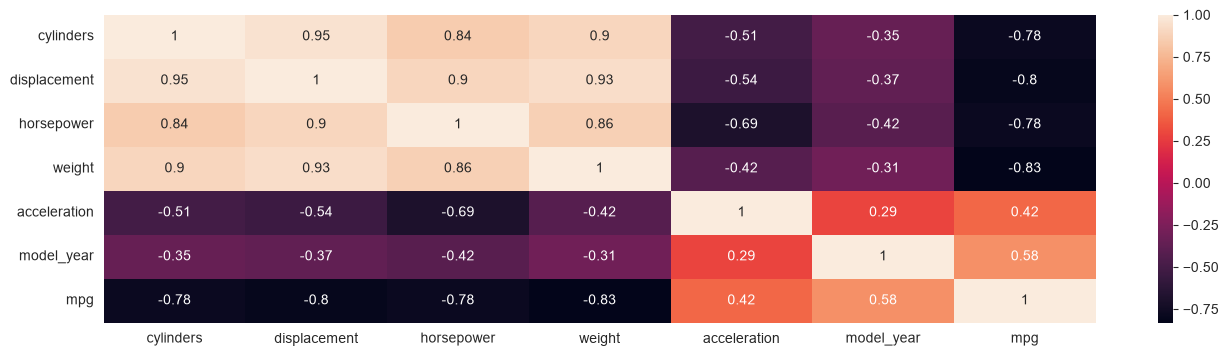

In [96]:

#Correlation between our variables
plt.figure(figsize=(16,4))
sns.heatmap(df.select_dtypes(include=np.number).corr(),annot=True)

<Axes: >

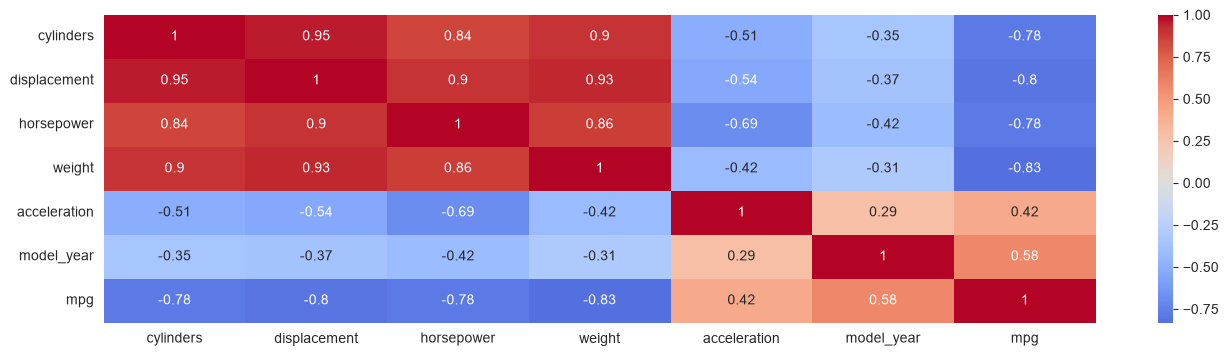

In [97]:
#Correlation between the variables 
plt.figure(figsize=(16,4))
sns.heatmap(df.select_dtypes(include=np.number).corr(),
            annot=True,
            cmap='coolwarm',
            center=0
           )

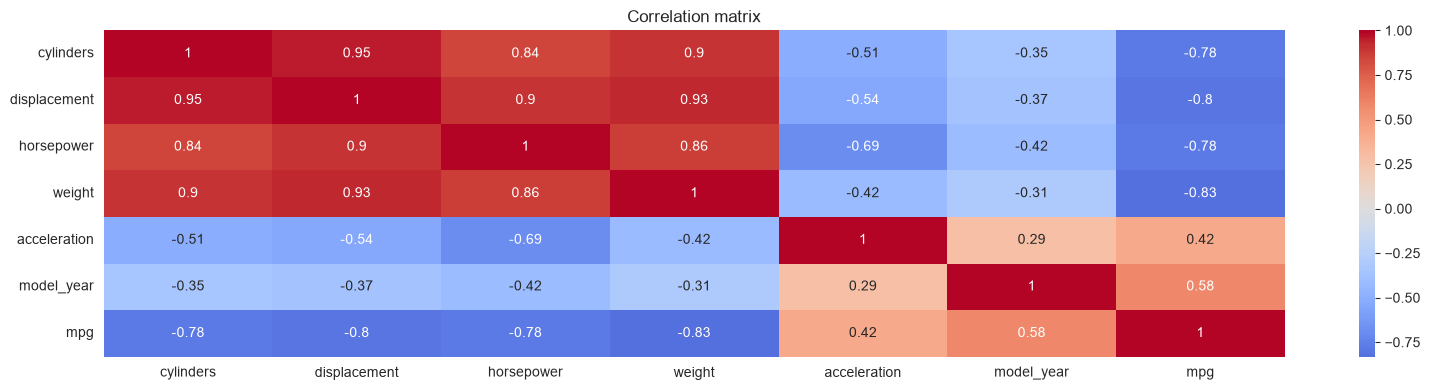

In [98]:
#Correlation between the variables 
plt.figure(figsize=(16,4))
sns.heatmap(df.select_dtypes(include=np.number).corr(),
            annot=True,
            cmap='coolwarm',
            center=0
           )
plt.title("Correlation matrix")
plt.tight_layout()
plt.show()

In [99]:
#Step:4: Dividing the data into train test split
print(X)
print(Y)
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)
print('\n train test Split')
print("Training data", len(X_train))
print("Tresting data", len(X_test))

     cylinders  displacement  horsepower  weight  acceleration  model_year  \
0            8         307.0       130.0    3504          12.0          70   
1            8         350.0       165.0    3693          11.5          70   
2            8         318.0       150.0    3436          11.0          70   
3            8         304.0       150.0    3433          12.0          70   
4            8         302.0       140.0    3449          10.5          70   
..         ...           ...         ...     ...           ...         ...   
393          4         140.0        86.0    2790          15.6          82   
394          4          97.0        52.0    2130          24.6          82   
395          4         135.0        84.0    2295          11.6          82   
396          4         120.0        79.0    2625          18.6          82   
397          4         119.0        82.0    2720          19.4          82   

    origin  
0        1  
1        1  
2        1  
3        1 

In [100]:
#Step:4: Dividing the data into train test split
#print(X)
#print(y)
#Split rule ---> 70-30,80-20,75-25
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)
print('\n train test Split')
print("Training data", len(X_train))
print("Tresting data", len(X_test))
#print(X_train)


 train test Split
Training data 318
Tresting data 80


In [101]:
#Step:5: Creating a baseline Model
def evaluate(model_name,actual,predicted):
    """Returns MAE,MSE,RMSE,R2-Score"""
    mse =  mean_squared_error(actual,predicted)
    mae =  mean_absolute_error(actual,predicted)
    return {'Model_Name': model_name,
    'MAE':mae,
    'MSE':mse,
    'RMSE':np.sqrt(mse),
    'R2-Score':r2_score(actual,predicted)}
results=[]

In [102]:
from sklearn.metrics import mean_squared_error

In [103]:
#Step:6: Baseline MOdel --> It predicts the training set for every values 
baseline_predictions=np.full(len(Y_test),Y_train.mean())
baseline_predictions
#in the above case we are keeping baseline prediction
results.append(evaluate("Mean baseline",Y_test,baseline_predictions))
#results
# in the above case we are creating the baseline predicted data

In [104]:
#Step:7: We apply Linear Regression 
simple_model = LinearRegression()
#we fit the data the model
simple_model.fit(X_train[['weight']],Y_train)
simple_model_predictions=simple_model.predict(X_test[['weight']])
#print(simple_model_predictions)
results.append(evaluate("Simple Linear Regression:Weight", Y_test, simple_model_predictions))
print(len(results))

2


In [105]:
results

[{'Model_Name': 'Mean baseline',
  'MAE': 5.955408805031446,
  'MSE': 53.98329798069697,
  'RMSE': np.float64(7.347332711991268),
  'R2-Score': -0.00403326341807686},
 {'Model_Name': 'Simple Linear Regression:Weight',
  'MAE': 3.1177861992064573,
  'MSE': 14.894861064636197,
  'RMSE': np.float64(3.859386099451077),
  'R2-Score': 0.722971057303075}]

In [106]:
#we will check the intercept value
print(f'Simple Linaer Regression Equation')
print(f"Predicted MPG = {simple_model.intercept_}+{simple_model.coef_[0]}*weight")

Simple Linaer Regression Equation
Predicted MPG = 46.78206336645047+-0.007805242351594879*weight


In [107]:
simple_model = LinearRegression()
#we fit the data the model
simple_model.fit(X_train[['cylinders']],Y_train)
simple_model_predictions_cylinders=simple_model.predict(X_test[['cylinders']])
#print(simple_model_predictions)
results.append(evaluate("Simple Linear Regression:Cylinders", Y_test, simple_model_predictions_cylinders))

In [108]:
results

[{'Model_Name': 'Mean baseline',
  'MAE': 5.955408805031446,
  'MSE': 53.98329798069697,
  'RMSE': np.float64(7.347332711991268),
  'R2-Score': -0.00403326341807686},
 {'Model_Name': 'Simple Linear Regression:Weight',
  'MAE': 3.1177861992064573,
  'MSE': 14.894861064636197,
  'RMSE': np.float64(3.859386099451077),
  'R2-Score': 0.722971057303075},
 {'Model_Name': 'Simple Linear Regression:Cylinders',
  'MAE': 3.5184964254890914,
  'MSE': 19.664864157034096,
  'RMSE': np.float64(4.434508333179012),
  'R2-Score': 0.6342539549673287}]

In [109]:
simple_model = LinearRegression()
#we fit the data the model
simple_model.fit(X_train[['displacement']],Y_train)
simple_model_predictions_displacement=simple_model.predict(X_test[['displacement']])
#print(simple_model_predictions)
results.append(evaluate("Simple Linear Regression:Displacement", Y_test, simple_model_predictions_displacement))

In [110]:
results

[{'Model_Name': 'Mean baseline',
  'MAE': 5.955408805031446,
  'MSE': 53.98329798069697,
  'RMSE': np.float64(7.347332711991268),
  'R2-Score': -0.00403326341807686},
 {'Model_Name': 'Simple Linear Regression:Weight',
  'MAE': 3.1177861992064573,
  'MSE': 14.894861064636197,
  'RMSE': np.float64(3.859386099451077),
  'R2-Score': 0.722971057303075},
 {'Model_Name': 'Simple Linear Regression:Cylinders',
  'MAE': 3.5184964254890914,
  'MSE': 19.664864157034096,
  'RMSE': np.float64(4.434508333179012),
  'R2-Score': 0.6342539549673287},
 {'Model_Name': 'Simple Linear Regression:Displacement',
  'MAE': 3.3949595383649607,
  'MSE': 18.102543998358946,
  'RMSE': np.float64(4.254708450453326),
  'R2-Score': 0.6633114869465596}]

In [111]:
#X['Horsepower'].fillna(X['horsepower'].mean(),inplace = True

In [119]:
#step8: multiple linear regression
#multiple Regression uses one or more independent vARIABLES WITH A linear plane
#polynomial regression uses power of a single variable  to fit a curved line,tough it is 
#calculated usinf linear eqation..

#we have miss numeric values in horsepower coloumn we will fillit
#we have origin column which is category -->festure encoding
from sklearn.pipeline import Pipeline
preprocessor = ColumnTransformer(transformers=[("numbers",SimpleImputer(strategy="median"),numerical_features),
    ("category",Pipeline(steps=[("imputer",SimpleImputer(strategy="most_frequent")),
    ("encoder",OneHotEncoder(handle_unknown="ignore",drop="first"),)]),categorical_features),])
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numbers', ...), ('category', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``featu

In [121]:
multiple_model = Pipeline(
    steps = [("prepare",preprocessor),
             ("model",LinearRegression())]
)
multiple_model.fit(X_train,Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prepare', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['cylinders','displacement','horsepower',...,'acceleration','model_year', 'origin']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numbers', ...), ('category', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This sub

In [122]:
#Step 9 : Polynomial Regression
#it forms a curvilinear realtionship
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
polynomial_model = Pipeline(
    steps = [("imputer",SimpleImputer(strategy = "median")),
             ("polynomial",PolynomialFeatures(include_bias=False)),
             ("model",LinearRegression())])
polynomial_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('polynomial', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto a

In [129]:
#Step:9: Polynomial Regression
#it forms a curvilinear relationship
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
polynomial_model = Pipeline(
    steps = [("imputer",SimpleImputer(strategy = "median")),
             ("polynomial", PolynomialFeatures(include_bias=False)),
             ("model",LinearRegression())])
#polynomial_model
#Selecting the polynomial degree
degree_search = GridSearchCV(
    polynomial_model,
    param_grid={'polynomial__degree':[2,3,4,5]},
    scoring="neg_mean_squared_error",
    cv=5)

In [130]:
degree_search

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'polynomial__degree': [2, 3, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information pri

In [132]:
degree_search.fit(X_train[['horsepower']],Y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'polynomial__degree': [2, 3, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information pri

In [135]:
degree_search.fit(X_train[['horsepower']],Y_train)
polynomial_predictions = degree_search.predict(X_test[['horsepower']])
results.append(evaluate("Polynomial : Horsepower",
                        Y_test,
                        polynomial_predictions))
results

[{'Model_Name': 'Mean baseline',
  'MAE': 5.955408805031446,
  'MSE': 53.98329798069697,
  'RMSE': np.float64(7.347332711991268),
  'R2-Score': -0.00403326341807686},
 {'Model_Name': 'Simple Linear Regression:Weight',
  'MAE': 3.1177861992064573,
  'MSE': 14.894861064636197,
  'RMSE': np.float64(3.859386099451077),
  'R2-Score': 0.722971057303075},
 {'Model_Name': 'Simple Linear Regression:Cylinders',
  'MAE': 3.5184964254890914,
  'MSE': 19.664864157034096,
  'RMSE': np.float64(4.434508333179012),
  'R2-Score': 0.6342539549673287},
 {'Model_Name': 'Simple Linear Regression:Displacement',
  'MAE': 3.3949595383649607,
  'MSE': 18.102543998358946,
  'RMSE': np.float64(4.254708450453326),
  'R2-Score': 0.6633114869465596},
 {'Model_Name': 'Polynomial : Horsepower',
  'MAE': 2.924901300821356,
  'MSE': 13.978713313447923,
  'RMSE': np.float64(3.7388117515392403),
  'R2-Score': 0.7400104537609868}]

In [136]:
#Finding out the best degree
best_degree = degree_search.best_params_['polynomial__degree']
cv_rmse = np.sqrt(-degree_search.best_score_)
print(best_degree)
print(cv_rmse)

2
4.620314169891041


In [137]:
#Finally we will print the results
results = pd.DataFrame(results).sort_values("RMSE")
results

,Model_Name,MAE,MSE,RMSE,R2-Score
4,Polynomial : Horsepower,2.924901,13.978713,3.738812,0.740010
1,Simple Linear Regression:Weight,3.117786,14.894861,3.859386,0.722971
3,Simple Linear Regression:Displacement,3.394960,18.102544,4.254708,0.663311
2,Simple Linear Regression:Cylinders,3.518496,19.664864,4.434508,0.634254
0,Mean baseline,5.955409,53.983298,7.347333,-0.004033
